# Two-Stage Stitching with Known Camera Positions

This notebook implements a two-stage stitching approach:
1. **Stage 1**: Spherical stitching within each ESP group (unchanged)
2. **Stage 2**: Position-based stitching using known ESP locations (front, left, right, back) with optional fine-tuning

The ESP cameras are positioned at approximately 90° intervals:
- ESP2: Front (0°)
- ESP3: Left (90°) 
- ESP1: Right (270°/-90°)
- ESP4: Back (180°)


In [7]:
import os
from pathlib import Path
from typing import List, Tuple, Dict, Optional
import time
import re
import math

import numpy as np
import cv2 as cv
from matplotlib import pyplot as plt

from stitching.feature_detector import FeatureDetector
from stitching.feature_matcher import FeatureMatcher
from stitching.camera_estimator import CameraEstimator
from stitching.camera_adjuster import CameraAdjuster
from stitching.camera_wave_corrector import WaveCorrector
from stitching.warper import Warper
from stitching.seam_finder import SeamFinder
from stitching.exposure_error_compensator import ExposureErrorCompensator
from stitching.blender import Blender
from stitching.subsetter import Subsetter

np.set_printoptions(suppress=True, linewidth=140)

def plot_image(img, figsize=(6,6), title=None):
    fig, ax = plt.subplots(figsize=figsize)
    if img.ndim == 2:
        ax.imshow(img, cmap='gray')
    else:
        ax.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    if title:
        ax.set_title(title)
    ax.axis('off')
    plt.show()

def plot_images(imgs, titles=None, figsize=(16,6)):
    n = len(imgs)
    fig, axs = plt.subplots(1, n, figsize=figsize)
    if n == 1:
        axs = [axs]
    for i, img in enumerate(imgs):
        if img.ndim == 2:
            axs[i].imshow(img, cmap='gray')
        else:
            axs[i].imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
        if titles is not None:
            axs[i].set_title(titles[i])
        axs[i].axis('off')
    plt.tight_layout()
    plt.show()

## Configuration and ESP-based image grouping

In [8]:
# Directory of input images
IMAGE_DIR = "final/data/calibration_run"  # change if needed
EXTS = (".jpg", ".jpeg", ".png", ".bmp")

# Optionally override with explicit list
IMAGE_PATHS: List[str] = []

# ESP Physical Positions (in degrees, 0° = front/north)
ESP_POSITIONS = {
    'esp_2': 0,      # Front
    'esp_3': 90,     # Left  
    'esp_1': 270,    # Right (-90°)
    'esp_4': 180     # Back
}

def list_images_sorted(image_dir: str) -> List[str]:
    files = [str(Path(image_dir) / f) for f in os.listdir(image_dir)
             if f.lower().endswith(EXTS) and not f.startswith('.')]
    files.sort()
    return files

def extract_esp_id(filename: str) -> str:
    """Extract ESP ID from filename like 'esp_1_timestamp.jpg' -> 'esp_1'"""
    basename = Path(filename).stem
    # Look for pattern like esp_X where X is a number
    match = re.match(r'(esp_\d+)', basename.lower())
    if match:
        return match.group(1)
    # Fallback: use first part before underscore if it contains 'esp'
    parts = basename.lower().split('_')
    for i, part in enumerate(parts):
        if 'esp' in part and i < len(parts) - 1:
            return f"{part}_{parts[i+1]}"
    # If no ESP pattern found, group by first part of filename
    return parts[0] if parts else "unknown"

def group_images_by_esp(image_paths: List[str]) -> Dict[str, List[str]]:
    """Group image paths by ESP device ID"""
    groups = {}
    for path in image_paths:
        esp_id = extract_esp_id(Path(path).name)
        if esp_id not in groups:
            groups[esp_id] = []
        groups[esp_id].append(path)
    return groups

if IMAGE_PATHS:
    imgs_list = [str(Path(p)) for p in IMAGE_PATHS]
else:
    imgs_list = list_images_sorted(IMAGE_DIR)

print(f"Found {len(imgs_list)} images")

# Group by ESP
esp_groups = group_images_by_esp(imgs_list)
print(f"\nGrouped into {len(esp_groups)} ESP devices:")
for esp_id, paths in esp_groups.items():
    position = ESP_POSITIONS.get(esp_id, "unknown")
    direction = {0: "Front", 90: "Left", 180: "Back", 270: "Right"}.get(position, f"{position}°")
    print(f"  {esp_id} ({direction}): {len(paths)} images")
    for i, path in enumerate(paths[:3]):  # Show first 3
        print(f"    • {Path(path).name}")
    if len(paths) > 3:
        print(f"    ... and {len(paths)-3} more")

assert len(esp_groups) >= 2, "Need at least two ESP groups to create final panorama"

Found 42 images

Grouped into 4 ESP devices:
  esp_1 (Right): 12 images
    • esp_1_1757157562687.jpg
    • esp_1_1757157562915.jpg
    • esp_1_1757157563438.jpg
    ... and 9 more
  esp_2 (Front): 12 images
    • esp_2_1757157562695.jpg
    • esp_2_1757157562819.jpg
    • esp_2_1757157563430.jpg
    ... and 9 more
  esp_3 (Left): 7 images
    • esp_3_1757157562669.jpg
    • esp_3_1757157562983.jpg
    • esp_3_1757157563605.jpg
    ... and 4 more
  esp_4 (Back): 11 images
    • esp_4_1757157562586.jpg
    • esp_4_1757157563076.jpg
    • esp_4_1757157563116.jpg
    ... and 8 more


## Stitching parameters

In [9]:
WORK_MPIX = 0.6  # Resolution for intra-ESP stitching
HIGH_MPIX = 1.2  # Higher resolution for final inter-ESP stitching
DETECTOR = "orb"   # orb | brisk | akaze | sift
N_FEATURES_INTRA = 3000  # Features for intra-ESP (high overlap)
N_FEATURES_INTER = 8000  # More features for inter-ESP (lower overlap)

def resize_to_megapix(img: np.ndarray, target_mpix: float, allow_upscale: bool = False) -> np.ndarray:
    if target_mpix is None or target_mpix <= 0:
        return img
    h, w = img.shape[:2]
    cur_mpix = (w * h) / 1e6
    if cur_mpix <= 0:
        return img
    scale = np.sqrt(target_mpix / cur_mpix)
    if scale >= 1.0 and not allow_upscale:
        return img
    new_w = max(1, int(round(w * scale)))
    new_h = max(1, int(round(h * scale)))
    interp = cv.INTER_AREA if scale < 1.0 else cv.INTER_LINEAR
    return cv.resize(img, (new_w, new_h), interpolation=interp)

## Stage 1: Spherical stitching within each ESP group (unchanged)


STAGE 1: Stitching ESP group 'esp_1' (12 images)
Image sizes: ['800x600', '800x600', '800x600']
Detecting features...
Features detected: [2157, 2002, 2242, 1254, 2059, 2472, 2487, 2501, 2528, 2638, 2599, 2453]
Matching features...
Pairwise matches: 128
Estimating cameras...
Adjusting cameras...
Warping images...
Finding seams...
Compensating exposure...
Blending...
ESP 'esp_1' stitching completed: 813x504
Saved: esp_esp_1_spherical.jpg


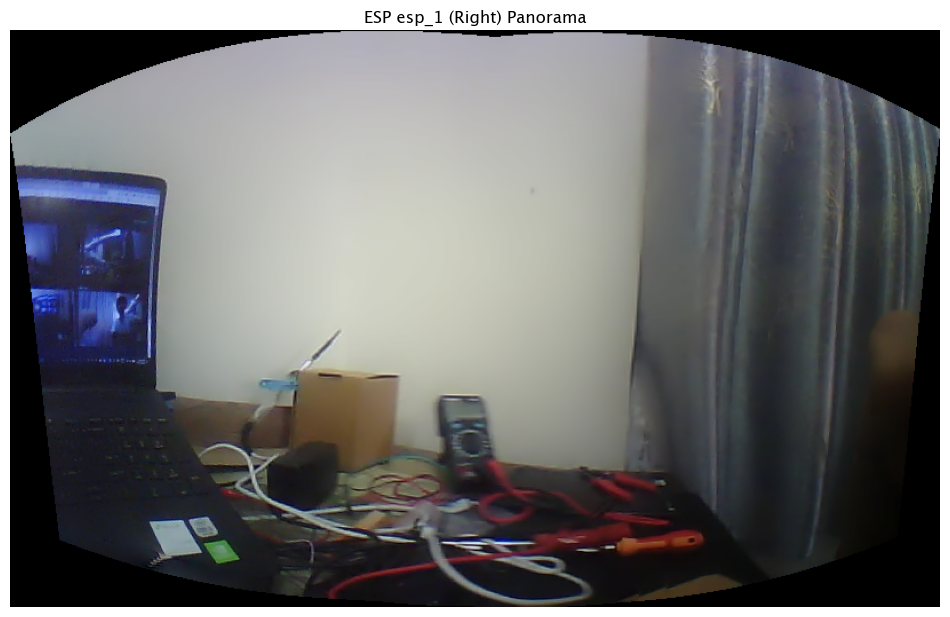


STAGE 1: Stitching ESP group 'esp_2' (12 images)
Image sizes: ['800x600', '800x600', '800x600']
Detecting features...
Features detected: [2797, 2755, 2671, 1873, 2555, 2517, 2440, 2512, 2444, 2551, 2482, 2402]
Matching features...
Pairwise matches: 130
Estimating cameras...
Adjusting cameras...
Warping images...
Finding seams...
Compensating exposure...
Blending...
ESP 'esp_2' stitching completed: 732x463
Saved: esp_esp_2_spherical.jpg


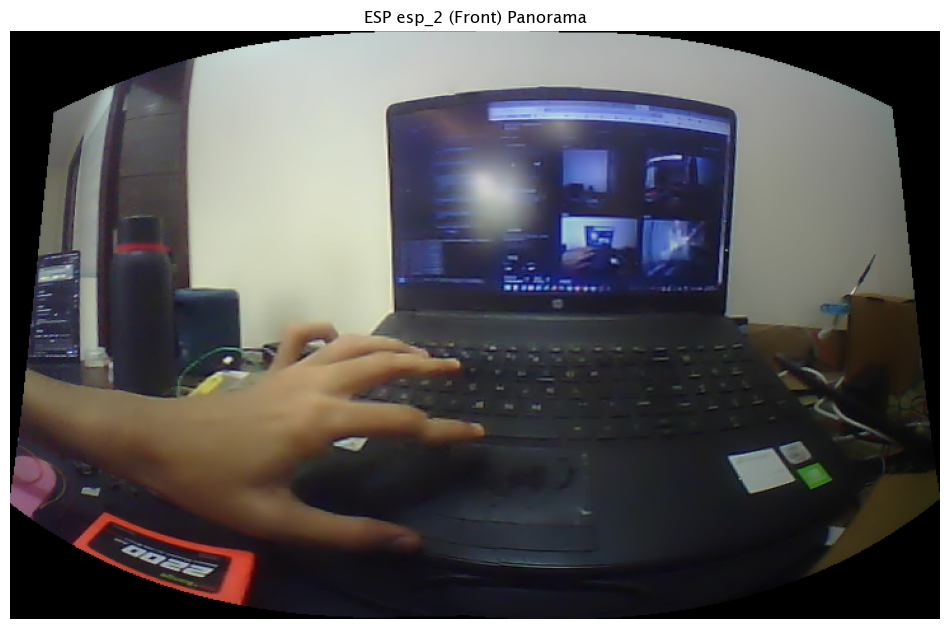


STAGE 1: Stitching ESP group 'esp_3' (7 images)
Image sizes: ['800x600', '800x600', '800x600']
Detecting features...
Features detected: [2885, 2859, 2950, 2715, 2985, 2986, 2991]
Matching features...
Pairwise matches: 42
Estimating cameras...
Adjusting cameras...
Warping images...
Finding seams...
Compensating exposure...
Blending...
ESP 'esp_3' stitching completed: 460x352
Saved: esp_esp_3_spherical.jpg


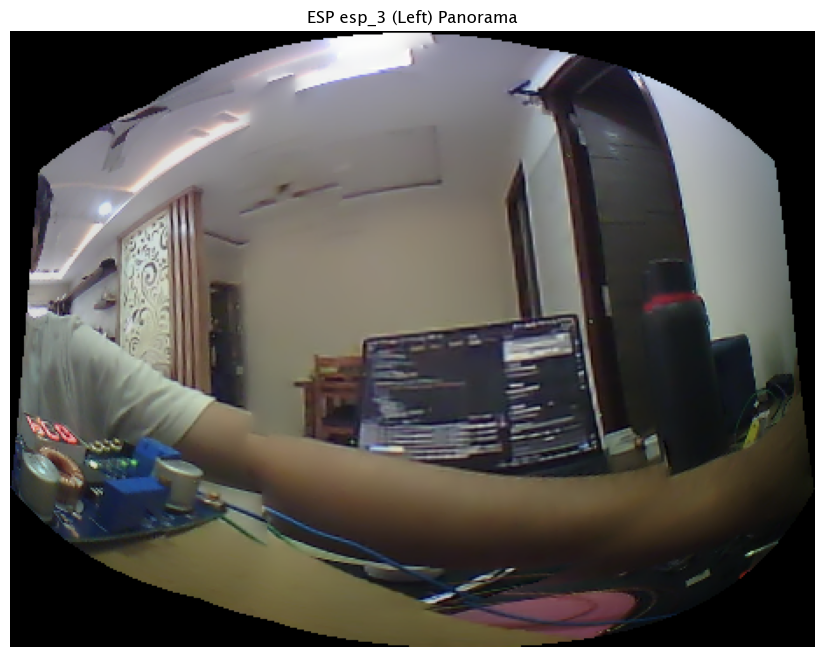


STAGE 1: Stitching ESP group 'esp_4' (11 images)
Image sizes: ['640x480', '640x480', '640x480']
Detecting features...
Features detected: [1981, 1763, 1418, 1628, 1041, 618, 793, 580, 733, 631, 500]
Matching features...
Pairwise matches: 108
Estimating cameras...
Adjusting cameras...
Warping images...
Finding seams...
Compensating exposure...
Blending...
ESP 'esp_4' stitching completed: 525x356
Saved: esp_esp_4_spherical.jpg


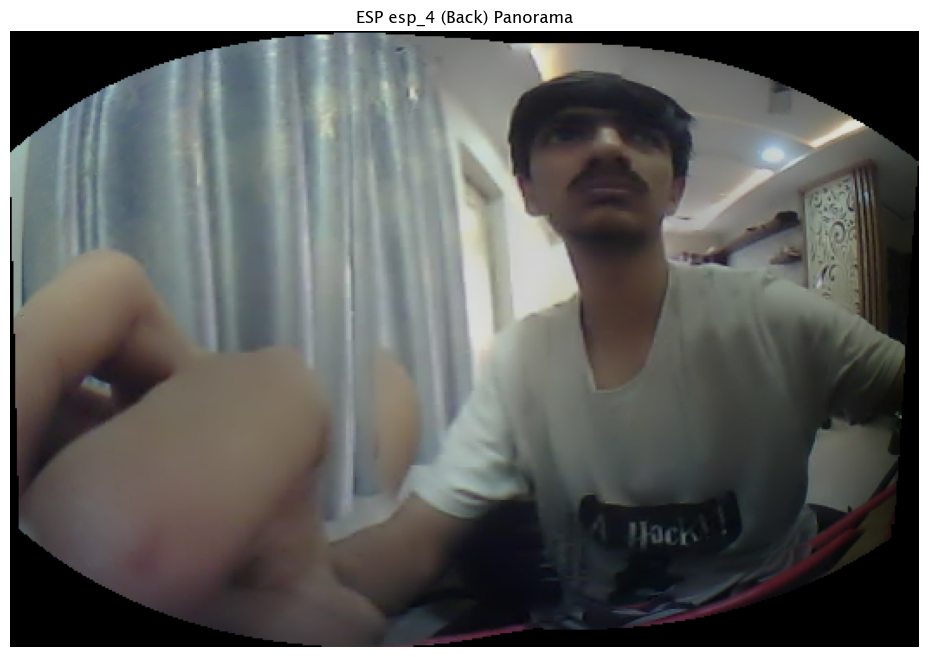


Stage 1 completed: 4 ESP panoramas created


In [10]:
def stitch_esp_group_spherical(image_paths: List[str], esp_id: str, work_mpix: float = 0.6) -> np.ndarray:
    """Stitch images from a single ESP using spherical projection"""
    print(f"\n{'='*60}")
    print(f"STAGE 1: Stitching ESP group '{esp_id}' ({len(image_paths)} images)")
    print(f"{'='*60}")
    
    if len(image_paths) == 1:
        img = cv.imread(image_paths[0], cv.IMREAD_COLOR)
        return resize_to_megapix(img, work_mpix, allow_upscale=False)
    
    # Load and resize images
    imgs = []
    for path in image_paths:
        img = cv.imread(path, cv.IMREAD_COLOR)
        if img is None:
            raise ValueError(f"Failed to read image: {path}")
        imgs.append(resize_to_megapix(img, work_mpix, allow_upscale=False))
    
    print(f"Image sizes: {[f'{img.shape[1]}x{img.shape[0]}' for img in imgs[:3]]}")
    
    try:
        # Use stitching library components
        finder = FeatureDetector(detector=DETECTOR, nfeatures=N_FEATURES_INTRA)
        matcher = FeatureMatcher(matcher_type="homography", range_width=-1)  # Match all pairs
        
        # Detect features
        print("Detecting features...")
        features = [finder.detect_features(img) for img in imgs]
        print(f"Features detected: {[len(f.keypoints) for f in features]}")
        
        # Match features
        print("Matching features...")
        matches = matcher.match_features(features)
        print(f"Pairwise matches: {len([m for m in matches if m.confidence > 0.3])}")
        
        # Keep only well-connected images
        subsetter = Subsetter(confidence_threshold=0.3)
        indices = subsetter.get_indices_to_keep(features, matches)
        
        if len(indices) != len(features):
            print(f"Keeping {len(indices)}/{len(features)} well-connected images")
            imgs = [imgs[i] for i in indices]
            features = [features[i] for i in indices]
            matches = subsetter.subset_matches(matches, indices)
        
        if len(imgs) < 2:
            print("Not enough connected images, returning first image")
            return imgs[0] if imgs else np.zeros((480, 640, 3), dtype=np.uint8)
        
        # Camera estimation
        print("Estimating cameras...")
        estimator = CameraEstimator()
        cameras = estimator.estimate(features, matches)
        
        # Camera adjustment
        print("Adjusting cameras...")
        adjuster = CameraAdjuster(confidence_threshold=0.3)
        try:
            cameras = adjuster.adjust(features, matches, cameras)
        except Exception as e:
            print(f"Camera adjustment failed, trying lower confidence: {e}")
            adjuster = CameraAdjuster(confidence_threshold=0.1)
            cameras = adjuster.adjust(features, matches, cameras)
        
        # Wave correction
        corrector = WaveCorrector()
        cameras = corrector.correct(cameras)
        
        # Warping
        print("Warping images...")
        warper = Warper("spherical")
        warper.set_scale(cameras)
        
        sizes = [(img.shape[1], img.shape[0]) for img in imgs]
        
        # Warp images and masks
        warped_imgs = list(warper.warp_images(imgs, cameras, aspect=1.0))
        warped_masks = list(warper.create_and_warp_masks(sizes, cameras, aspect=1.0))
        corners, sizes_out = warper.warp_rois(sizes, cameras, aspect=1.0)
        
        # Seam finding
        print("Finding seams...")
        seam_finder = SeamFinder()
        seam_masks = seam_finder.find(warped_imgs, corners, warped_masks)
        
        # Exposure compensation
        print("Compensating exposure...")
        compensator = ExposureErrorCompensator()
        compensator.feed(corners, warped_imgs, warped_masks)
        compensated_imgs = [
            compensator.apply(i, corner, img, mask)
            for i, (img, mask, corner) in enumerate(zip(warped_imgs, warped_masks, corners))
        ]
        
        # Blending
        print("Blending...")
        blender = Blender()
        blender.prepare(corners, sizes_out)
        for img, mask, corner in zip(compensated_imgs, seam_masks, corners):
            blender.feed(img, mask, corner)
        
        result, _ = blender.blend()
        
        print(f"ESP '{esp_id}' stitching completed: {result.shape[1]}x{result.shape[0]}")
        
        # Save intermediate result
        out_path = f"esp_{esp_id}_spherical.jpg"
        cv.imwrite(out_path, result)
        print(f"Saved: {out_path}")
        
        return result
        
    except Exception as e:
        print(f"Spherical stitching failed for ESP '{esp_id}': {e}")
        print("Falling back to simple panorama...")
        
        # Fallback: simple homography-based stitching
        if len(imgs) >= 2:
            result = imgs[0]
            for i in range(1, len(imgs)):
                result = simple_stitch_pair(result, imgs[i])
            return result
        return imgs[0] if imgs else np.zeros((480, 640, 3), dtype=np.uint8)

def simple_stitch_pair(img1, img2, detector_type="orb", n_features=2000):
    """Simple homography-based stitching of two images"""
    # Create detector
    if detector_type.lower() == "orb":
        detector = cv.ORB_create(nfeatures=n_features)
        norm = cv.NORM_HAMMING
    elif detector_type.lower() == "sift":
        detector = cv.SIFT_create(nfeatures=n_features)
        norm = cv.NORM_L2
    else:
        detector = cv.ORB_create(nfeatures=n_features)
        norm = cv.NORM_HAMMING
    
    # Detect and match
    kp1, desc1 = detector.detectAndCompute(img1, None)
    kp2, desc2 = detector.detectAndCompute(img2, None)
    
    if desc1 is None or desc2 is None or len(kp1) < 4 or len(kp2) < 4:
        # No features, just concatenate
        return np.hstack([img1, img2])
    
    # Handle UMat objects
    if hasattr(desc1, 'get'):
        desc1 = desc1.get()
    if hasattr(desc2, 'get'):
        desc2 = desc2.get()
    
    # Ensure descriptors are numpy arrays
    if not isinstance(desc1, np.ndarray):
        desc1 = np.array(desc1)
    if not isinstance(desc2, np.ndarray):
        desc2 = np.array(desc2)
    
    if desc1.shape[0] == 0 or desc2.shape[0] == 0:
        return np.hstack([img1, img2])
    
    bf = cv.BFMatcher(norm, crossCheck=False)
    matches = bf.knnMatch(desc1, desc2, k=2)
    
    # Ratio test
    good = []
    for m in matches:
        if len(m) == 2 and m[0].distance < 0.75 * m[1].distance:
            good.append(m[0])
    
    if len(good) < 4:
        return np.hstack([img1, img2])
    
    # Homography
    src_pts = np.float32([kp1[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)
    
    H, mask = cv.findHomography(dst_pts, src_pts, cv.RANSAC, 5.0)
    if H is None:
        return np.hstack([img1, img2])
    
    # Ensure H is float32
    H = H.astype(np.float32)
    
    # Warp and blend
    h1, w1 = img1.shape[:2]
    h2, w2 = img2.shape[:2]
    
    corners2 = np.float32([[0, 0], [w2, 0], [w2, h2], [0, h2]]).reshape(-1, 1, 2)
    corners2_transformed = cv.perspectiveTransform(corners2, H).reshape(-1, 2)
    
    corners1 = np.float32([[0, 0], [w1, 0], [w1, h1], [0, h1]])
    
    all_corners = np.vstack([corners1, corners2_transformed])
    [x_min, y_min] = np.int32(all_corners.min(axis=0).ravel())
    [x_max, y_max] = np.int32(all_corners.max(axis=0).ravel())
    
    # Ensure translation values are valid
    translation = [float(-x_min), float(-y_min)]
    H_translate = np.array([[1.0, 0.0, translation[0]], 
                           [0.0, 1.0, translation[1]], 
                           [0.0, 0.0, 1.0]], dtype=np.float32)
    
    result_width = int(x_max - x_min)
    result_height = int(y_max - y_min)
    
    # Ensure dimensions are positive
    if result_width <= 0 or result_height <= 0:
        return np.hstack([img1, img2])
    
    # Limit maximum size to prevent memory issues
    max_dimension = 10000
    if result_width > max_dimension or result_height > max_dimension:
        print(f"Warning: Result too large ({result_width}x{result_height}), concatenating instead")
        return np.hstack([img1, img2])
    
    try:
        img1_warped = cv.warpPerspective(img1, H_translate, (result_width, result_height))
        img2_warped = cv.warpPerspective(img2, H_translate.dot(H), (result_width, result_height))
        
        # Simple blending
        mask1 = (img1_warped.sum(axis=2) > 0)
        mask2 = (img2_warped.sum(axis=2) > 0)
        overlap = mask1 & mask2
        
        result = img1_warped.copy()
        result[mask2 & (~mask1)] = img2_warped[mask2 & (~mask1)]
        if np.any(overlap):
            result[overlap] = ((img1_warped[overlap].astype(np.float32) + 
                               img2_warped[overlap].astype(np.float32)) / 2).astype(np.uint8)
        
        return result
        
    except Exception as e:
        print(f"Warping failed: {e}, falling back to concatenation")
        return np.hstack([img1, img2])

# Stitch each ESP group
esp_panoramas = {}
for esp_id, image_paths in esp_groups.items():
    panorama = stitch_esp_group_spherical(image_paths, esp_id, WORK_MPIX)
    esp_panoramas[esp_id] = panorama
    
    # Show result
    position = ESP_POSITIONS.get(esp_id, "unknown")
    direction = {0: "Front", 90: "Left", 180: "Back", 270: "Right"}.get(position, f"{position}°")
    plot_image(panorama, figsize=(12, 8), title=f"ESP {esp_id} ({direction}) Panorama")

print(f"\nStage 1 completed: {len(esp_panoramas)} ESP panoramas created")

## Stage 2: Position-based stitching with optional fine-tuning

Starting Stage 2: Position-based inter-ESP stitching...

STAGE 2: Position-based stitching of 4 ESP panoramas
Creating position-based cameras:
  ESP esp_2 (Front, 0°): focal=250.0
  ESP esp_3 (Left, 90°): focal=250.0
  ESP esp_4 (Back, 180°): focal=250.0
  ESP esp_1 (Right, 270°): focal=250.0

Attempting fine-tuning with 8000 features...
Features detected: [2404, 2154, 649, 1798]
conf_matrix after get_confidence_matrix: [[0.         0.41916168 0.37267081 0.90128755]
 [0.41916168 0.         1.28755365 0.48951049]
 [0.37267081 1.28755365 0.         0.30487805]
 [0.90128755 0.48951049 0.30487805 0.        ]]
16
Good matches found: 4


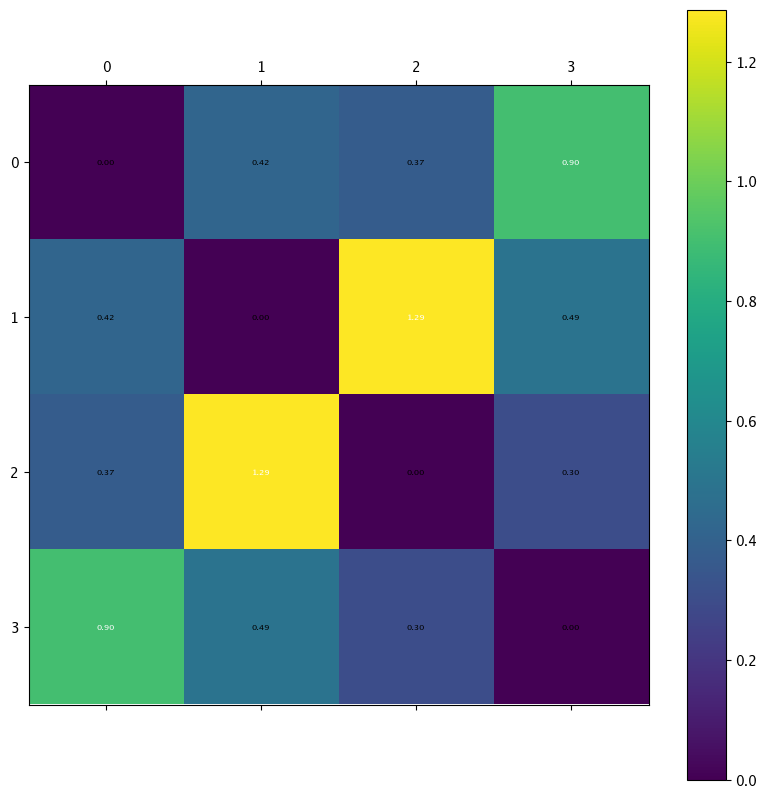

Attempting camera adjustment...
Fine-tuning failed: Camera parameters adjusting failed.
Using position-based cameras without adjustment
ESP esp_2: 732x463
ESP esp_3: 460x352
ESP esp_4: 525x356
ESP esp_1: 813x504
Applying wave correction...
Warping images to spherical projection...
Warped image count: 4
Corner positions: [(-785, 205), (206, 239), (-202, 238), (-647, 195)]
Finding optimal seams...
Compensating exposure differences...
Blending images...
Position-based stitching successful: 1570x395


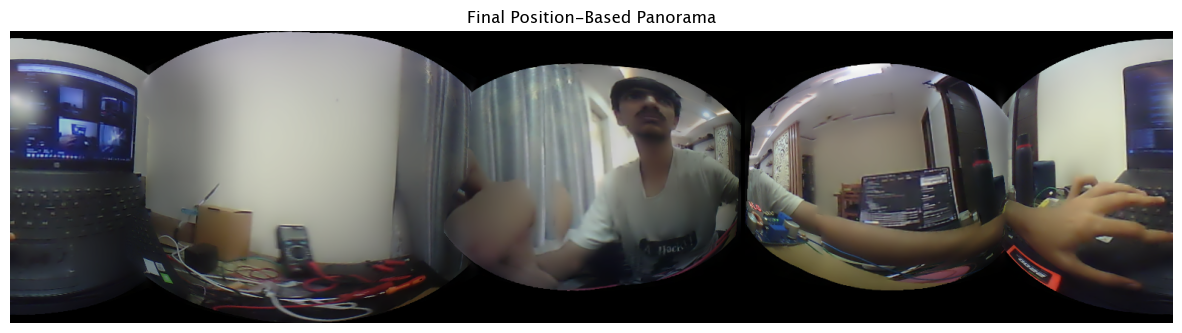


Final panorama saved: final_position_based_panorama.jpg
Final size: 1570x395


In [44]:
from cv2.detail import BundleAdjusterReproj
class Camera:
    """Simple camera representation for stitching library compatibility"""
    def __init__(self, focal=1000, ppx=0, ppy=0, aspect=1.0, R=None, t=None):
        self.focal = focal
        self.aspect = aspect
        self.ppx = ppx
        self.ppy = ppy
        if R is not None:
            self.R = R.copy()
        else:
            self.R = np.eye(3, dtype=np.float32)
        if t is not None:
            self.t = t.copy()
        else:
            self.t = np.zeros(3, dtype=np.float32)
            
    @property
    def K(self):
        return np.array([
            [self.focal, 0, self.ppx],
            [0, self.focal * self.aspect, self.ppy],
            [0, 0, 1]
        ], dtype=np.float32)

def create_position_based_cameras(panoramas, positions, base_focal=1000):
    """Create OpenCV-compatible cameras based on known ESP positions"""
    cameras = []
    esp_ids = []
    
    sorted_esps = sorted([(esp_id, pos) for esp_id, pos in positions.items() 
                         if esp_id in panoramas], key=lambda x: x[1])
    
    print("Creating position-based cameras:")
    for esp_id, angle_deg in sorted_esps:
        esp_ids.append(esp_id)
        
        # Rotation matrix (Y-axis rotation)
        angle_rad = np.radians(angle_deg)
        cos_a, sin_a = np.cos(-angle_rad), np.sin(-angle_rad)
        R = np.array([[cos_a, 0, sin_a],
                      [0, 1, 0],
                      [-sin_a, 0, cos_a]], dtype=np.float32)
        
        # Image size → principal point
        h, w = panoramas[esp_id].shape[:2]
        
        # Construct OpenCV CameraParams
        cam = cv.detail_CameraParams()
        cam.focal = base_focal
        cam.aspect = 1.0
        cam.ppx = w / 2.0
        cam.ppy = h / 2.0
        cam.R = R
        cam.t = np.zeros((3, 1), np.float32)  # no translation
        
        cameras.append(cam)
        
        direction = {0: "Front", 90: "Left", 180: "Back", 270: "Right"}.get(angle_deg, f"{angle_deg}°")
        print(f"  ESP {esp_id} ({direction}, {angle_deg}°): focal={cam.focal}")
    
    return cameras, esp_ids


def try_fine_tune_cameras(cameras: List[Camera], 
                         esp_ids: List[str],
                         panoramas: Dict[str, np.ndarray],
                         detector_type: str = "orb",
                         n_features: int = 5000) -> List[Camera]:
    """Try to fine-tune camera positions using feature matches"""
    print(f"\nAttempting fine-tuning with {n_features} features...")
    
    try:
        # Prepare images
        imgs = [resize_to_megapix(panoramas[esp_id], 1.2, allow_upscale=False) 
                for esp_id in esp_ids]
        
        # Detect features
        if detector_type == "orb":
            finder = FeatureDetector(detector=detector_type, nfeatures=n_features)
        else:
            finder = FeatureDetector(detector=detector_type)
        features = [finder.detect_features(img) for img in imgs]
        
        feature_counts = [len(f.keypoints) for f in features]
        print(f"Features detected: {feature_counts}")
        
        if min(feature_counts) < 100:
            print("Too few features for fine-tuning, using position-based cameras")
            return cameras
        
        # Match features
        matcher = FeatureMatcher(matcher_type="homography", range_width=-1)
        matches_dbg = matcher.match_features(features)
        conf_matrix = matcher.get_confidence_matrix(matches_dbg)
        print("conf_matrix after get_confidence_matrix:", conf_matrix)
        
        # Count good matches
        print(len([m.confidence for m in matches_dbg]))
        good_matches = [m for m in matches_dbg if m.confidence > 0.5]
        print(f"Good matches found: {len(good_matches)}")
        
        fig, ax = plt.subplots(figsize=(min(12, 2+2*conf_matrix.shape[0]), min(12, 2+2*conf_matrix.shape[1])))
        cax = ax.matshow(conf_matrix, interpolation='nearest')
        fig.colorbar(cax)
        for (i, j), z in np.ndenumerate(conf_matrix):
            ax.text(j, i, f"{z:0.2f}", ha='center', va='center', fontsize=6, color="white" if z > 0.5 else "black")
        plt.show()
        
        if len(good_matches) < 2:
            print("Too few matches for fine-tuning, using position-based cameras")
            return cameras
        
        # Try camera adjustment with low confidence threshold
        print("Attempting camera adjustment...")
        adjuster = CameraAdjuster(confidence_threshold=0.001)
        adjusted_cameras = adjuster.adjust(features, matches_dbg, cameras)
        
        print("Fine-tuning successful!")
        return adjusted_cameras
        
    except Exception as e:
        print(f"Fine-tuning failed: {e}")
        print("Using position-based cameras without adjustment")
        return cameras

def stitch_with_position_based_cameras(panoramas: Dict[str, np.ndarray], 
                                     positions: Dict[str, float],
                                     high_mpix: float = 1.2,
                                     try_fine_tune: bool = True) -> np.ndarray:
    """Stitch ESP panoramas using known positions with optional fine-tuning"""
    print(f"\n{'='*60}")
    print(f"STAGE 2: Position-based stitching of {len(panoramas)} ESP panoramas")
    print(f"{'='*60}")
    
    if len(panoramas) == 1:
        return list(panoramas.values())[0]
    
    # Create position-based cameras
    cameras, esp_ids = create_position_based_cameras(panoramas, positions, 250)
    
    if try_fine_tune:
        # Try to fine-tune cameras using feature matches
        # detectors - orb | brisk | akaze | sift
        cameras = try_fine_tune_cameras(cameras, esp_ids, panoramas, "orb", N_FEATURES_INTER)
    
    # Prepare images at high resolution
    imgs = []
    for esp_id in esp_ids:
        img = resize_to_megapix(panoramas[esp_id], high_mpix, allow_upscale=False)
        imgs.append(img)
        h, w = img.shape[:2]
        print(f"ESP {esp_id}: {w}x{h}")
    
    try:
        # Apply wave correction to smooth out any discontinuities
        print("Applying wave correction...")
        corrector = WaveCorrector()
        cameras = corrector.correct(cameras)
        
        # Warping using spherical projection
        print("Warping images to spherical projection...")
        warper = Warper("spherical")
        warper.set_scale(cameras)
        
        sizes = [(img.shape[1], img.shape[0]) for img in imgs]
        
        # Warp images and masks
        warped_imgs = list(warper.warp_images(imgs, cameras, aspect=1.0))
        warped_masks = list(warper.create_and_warp_masks(sizes, cameras, aspect=1.0))
        corners, sizes_out = warper.warp_rois(sizes, cameras, aspect=1.0)
        
        print(f"Warped image count: {len(warped_imgs)}")
        print(f"Corner positions: {corners}")
        
        # Seam finding
        print("Finding optimal seams...")
        seam_finder = SeamFinder()
        seam_masks = seam_finder.find(warped_imgs, corners, warped_masks)
        
        # Exposure compensation
        print("Compensating exposure differences...")
        compensator = ExposureErrorCompensator()
        compensator.feed(corners, warped_imgs, warped_masks)
        compensated_imgs = [
            compensator.apply(i, corner, img, mask)
            for i, (img, mask, corner) in enumerate(zip(warped_imgs, warped_masks, corners))
        ]
        
        # Blending
        print("Blending images...")
        blender = Blender()
        blender.prepare(corners, sizes_out)
        for img, mask, corner in zip(compensated_imgs, seam_masks, corners):
            blender.feed(img, mask, corner)
        
        result, _ = blender.blend()
        
        print(f"Position-based stitching successful: {result.shape[1]}x{result.shape[0]}")
        return result
        
    except Exception as e:
        print(f"Position-based spherical stitching failed: {e}")
        print("Falling back to simple sequential stitching...")
        
        # Fallback: sequential homography stitching in angular order
        result = imgs[0]
        for i in range(1, len(imgs)):
            print(f"Stitching ESP {esp_ids[0]} with ESP {esp_ids[i]}...")
            result = simple_stitch_pair(result, imgs[i], DETECTOR, N_FEATURES_INTER)
        
        return result

# Perform Stage 2 stitching using position information
print("Starting Stage 2: Position-based inter-ESP stitching...")
final_panorama = stitch_with_position_based_cameras(
    esp_panoramas, 
    ESP_POSITIONS, 
    HIGH_MPIX,
    try_fine_tune=True  # Set to False to skip fine-tuning
)

# Show final result
plot_image(final_panorama, figsize=(15, 10), title="Final Position-Based Panorama")

# Save final result
final_output_path = "final_position_based_panorama.jpg"
cv.imwrite(final_output_path, final_panorama)
print(f"\nFinal panorama saved: {final_output_path}")
print(f"Final size: {final_panorama.shape[1]}x{final_panorama.shape[0]}")

## Summary and Analysis

In [20]:
print(f"\n{'='*80}")
print("POSITION-BASED TWO-STAGE STITCHING SUMMARY")
print(f"{'='*80}")
print(f"Stage 1 (Intra-ESP spherical stitching):")
for esp_id, panorama in esp_panoramas.items():
    h, w = panorama.shape[:2]
    position = ESP_POSITIONS.get(esp_id, "unknown")
    direction = {0: "Front", 90: "Left", 180: "Back", 270: "Right"}.get(position, f"{position}°")
    print(f"  ESP {esp_id} ({direction}): {len(esp_groups[esp_id])} images → {w}x{h} panorama")

print(f"\nStage 2 (Position-based inter-ESP stitching):")
print(f"  Used known camera positions: Front(0°), Left(90°), Right(270°), Back(180°)")
print(f"  {len(esp_panoramas)} ESP panoramas → {final_panorama.shape[1]}x{final_panorama.shape[0]} final panorama")

print(f"\nAdvantages of position-based approach:")
print("  • Robust even with minimal feature overlap between ESP groups")
print("  • Uses physical knowledge to initialize camera orientations")
print("  • Optional fine-tuning with available feature matches")
print("  • More predictable and stable results")
print("  • Handles 360° coverage systematically")
print("  • Reduces dependency on feature detection quality")

print(f"\nTechnical details:")
print("  • ESP cameras positioned at ~90° intervals around a central point")
print("  • Each ESP camera rotation matrix created from known angular position")
print("  • Optional feature-based fine-tuning for minor adjustments")
print("  • Spherical warping preserves the 360° nature of the capture")
print("  • Wave correction smooths any remaining discontinuities")


POSITION-BASED TWO-STAGE STITCHING SUMMARY
Stage 1 (Intra-ESP spherical stitching):
  ESP esp_1 (Right): 12 images → 813x504 panorama
  ESP esp_2 (Front): 12 images → 732x463 panorama
  ESP esp_3 (Left): 7 images → 460x352 panorama
  ESP esp_4 (Back): 11 images → 525x356 panorama

Stage 2 (Position-based inter-ESP stitching):
  Used known camera positions: Front(0°), Left(90°), Right(270°), Back(180°)
  4 ESP panoramas → 1570x395 final panorama

Advantages of position-based approach:
  • Robust even with minimal feature overlap between ESP groups
  • Uses physical knowledge to initialize camera orientations
  • Optional fine-tuning with available feature matches
  • More predictable and stable results
  • Handles 360° coverage systematically
  • Reduces dependency on feature detection quality

Technical details:
  • ESP cameras positioned at ~90° intervals around a central point
  • Each ESP camera rotation matrix created from known angular position
  • Optional feature-based fine-tun

## Optional: Compare with different settings


EXPERIMENT: Pure position-based (no fine-tuning)

STAGE 2: Position-based stitching of 4 ESP panoramas
Creating position-based cameras:
  ESP esp_2 (Front, 0°): focal=250.0
  ESP esp_3 (Left, 90°): focal=250.0
  ESP esp_4 (Back, 180°): focal=250.0
  ESP esp_1 (Right, 270°): focal=250.0
ESP esp_2: 732x463
ESP esp_3: 460x352
ESP esp_4: 525x356
ESP esp_1: 813x504
Applying wave correction...
Warping images to spherical projection...
Warped image count: 4
Corner positions: [(-785, 205), (206, 239), (-202, 238), (-647, 195)]
Finding optimal seams...
Compensating exposure differences...
Blending images...
Position-based stitching successful: 1570x395


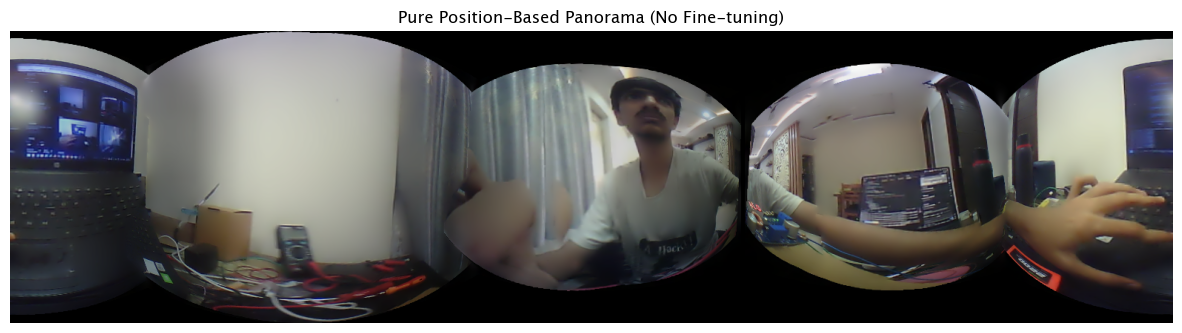

Pure position-based panorama saved: final_pure_position_panorama.jpg


In [21]:
# You can experiment with different parameters:

# Try without fine-tuning (pure position-based)
print(f"\n{'='*60}")
print("EXPERIMENT: Pure position-based (no fine-tuning)")
print(f"{'='*60}")

final_panorama_pure = stitch_with_position_based_cameras(
    esp_panoramas, 
    ESP_POSITIONS, 
    HIGH_MPIX,
    try_fine_tune=False
)

plot_image(final_panorama_pure, figsize=(15, 10), title="Pure Position-Based Panorama (No Fine-tuning)")

# Save pure position-based result
pure_output_path = "final_pure_position_panorama.jpg"
cv.imwrite(pure_output_path, final_panorama_pure)
print(f"Pure position-based panorama saved: {pure_output_path}")

## Advanced: Custom position adjustment

In [80]:
def create_custom_position_cameras(panoramas: Dict[str, np.ndarray], 
                                 custom_positions: Dict[str, Tuple[float, float, float]]) -> List[Camera]:
    """Create cameras with custom pan, tilt, roll adjustments"""
    cameras = []
    esp_ids = []
    
    print(f"Creating custom position cameras:")
    for esp_id, (pan, tilt, roll, focal) in custom_positions.items():
        if esp_id not in panoramas:
            continue
            
        esp_ids.append(esp_id)
        
        # Convert angles to radians
        pan_rad = np.radians(pan)
        tilt_rad = np.radians(tilt)  
        roll_rad = np.radians(roll)
        
        # Create rotation matrices
        # Pan (Y-axis rotation)
        R_pan = np.array([[np.cos(-pan_rad), 0, np.sin(-pan_rad)],
                          [0, 1, 0],
                          [-np.sin(-pan_rad), 0, np.cos(-pan_rad)]], dtype=np.float32)
        
        # Tilt (X-axis rotation)  
        R_tilt = np.array([[1, 0, 0],
                           [0, np.cos(-tilt_rad), -np.sin(-tilt_rad)],
                           [0, np.sin(-tilt_rad), np.cos(-tilt_rad)]], dtype=np.float32)
        
        # Roll (Z-axis rotation)
        R_roll = np.array([[np.cos(-roll_rad), -np.sin(-roll_rad), 0],
                           [np.sin(-roll_rad), np.cos(-roll_rad), 0],
                           [0, 0, 1]], dtype=np.float32)
        
        # Combined rotation: R = R_roll * R_tilt * R_pan
        R = R_roll @ R_tilt @ R_pan
        
        # Get image size for principal point
        h, w = panoramas[esp_id].shape[:2]
        
        # Construct OpenCV CameraParams
        cam = cv.detail_CameraParams()
        cam.focal = focal
        cam.aspect = 1.0
        cam.ppx = w / 2.0
        cam.ppy = h / 2.0
        cam.R = R
        cam.t = np.zeros((3, 1), np.float32)  # no translation
        
        cameras.append(cam)
        print(f"  ESP {esp_id}: pan={pan}°, tilt={tilt}°, roll={roll}°")
    
    return cameras, esp_ids

# Example: Fine adjustments to the base positions
# You can modify these values if the initial result needs tweaking
CUSTOM_POSITIONS = {
    'esp_2': (0, 0, 0, 250),      # Front: pan=0°, tilt=0°, roll=0°, focal = 250
    'esp_3': (80, 0, 0, 220),     # Left: pan=90°, tilt=0°, roll=0°, focal = 250
    'esp_4': (165, 0, 0, 220),     # Back: pan=180°, tilt=0°, roll=0°, focal = 250
    'esp_1': (270, 0, 0, 250)    # Right: pan=270°, tilt=0°, roll=0°, focal = 250
}

# Uncomment to try custom positions:
print(f"\n{'='*60}")
print("EXPERIMENT: Custom position adjustments")
print(f"{'='*60}")

# custom_cameras, custom_esp_ids = create_custom_position_cameras(esp_panoramas, CUSTOM_POSITIONS, 250)
# ... (rest of stitching pipeline would go here)

print(f"\nTo experiment with custom positions:")
print(f"1. Modify the CUSTOM_POSITIONS dictionary above")
print(f"2. Uncomment the custom position experiment section")
print(f"3. Adjust pan/tilt/roll values as needed:")
print(f"   - Pan: horizontal rotation (0°=front, 90°=left, 180°=back, 270°=right)")
print(f"   - Tilt: vertical rotation (positive=up, negative=down)")
print(f"   - Roll: camera rotation around viewing axis")


EXPERIMENT: Custom position adjustments

To experiment with custom positions:
1. Modify the CUSTOM_POSITIONS dictionary above
2. Uncomment the custom position experiment section
3. Adjust pan/tilt/roll values as needed:
   - Pan: horizontal rotation (0°=front, 90°=left, 180°=back, 270°=right)
   - Tilt: vertical rotation (positive=up, negative=down)
   - Roll: camera rotation around viewing axis


Starting Stage 2: Custom Position-based inter-ESP stitching...

STAGE 2: Position-based stitching of 4 ESP panoramas
Creating custom position cameras:
  ESP esp_2: pan=0°, tilt=0°, roll=0°
  ESP esp_3: pan=80°, tilt=0°, roll=0°
  ESP esp_4: pan=165°, tilt=0°, roll=0°
  ESP esp_1: pan=270°, tilt=0°, roll=0°
ESP esp_2: 732x463
ESP esp_3: 460x352
ESP esp_4: 525x356
ESP esp_1: 813x504
Applying wave correction...
Warping images to spherical projection...
Warped image count: 4
Corner positions: [(-25, 193), (-314, 210), (-678, 209), (-738, 183)]
Finding optimal seams...
Compensating exposure differences...
Blending images...
Position-based stitching successful: 1476x372


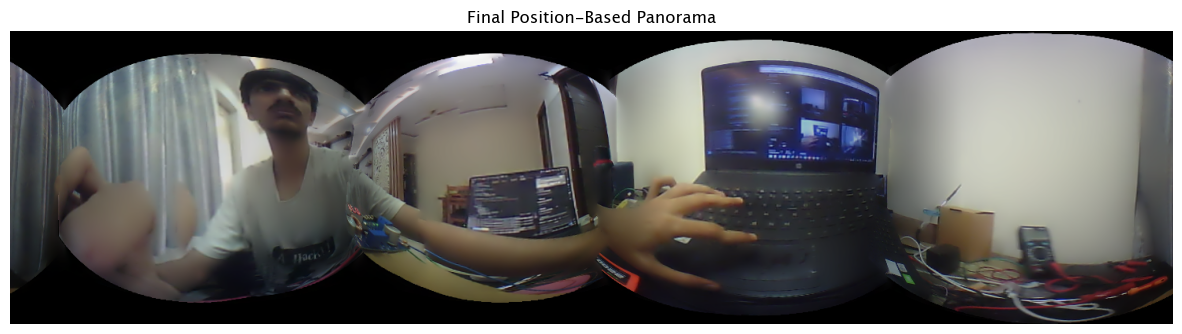


Final panorama saved: final_custom_position_based_panorama.jpg
Final size: 1476x372


In [81]:
from cv2.detail import BundleAdjusterReproj
class Camera:
    """Simple camera representation for stitching library compatibility"""
    def __init__(self, focal=1000, ppx=0, ppy=0, aspect=1.0, R=None, t=None):
        self.focal = focal
        self.aspect = aspect
        self.ppx = ppx
        self.ppy = ppy
        if R is not None:
            self.R = R.copy()
        else:
            self.R = np.eye(3, dtype=np.float32)
        if t is not None:
            self.t = t.copy()
        else:
            self.t = np.zeros(3, dtype=np.float32)
            
    @property
    def K(self):
        return np.array([
            [self.focal, 0, self.ppx],
            [0, self.focal * self.aspect, self.ppy],
            [0, 0, 1]
        ], dtype=np.float32)

def stitch_with_position_based_cameras(panoramas: Dict[str, np.ndarray],
                                     high_mpix: float = 1.2) -> np.ndarray:
    """Stitch ESP panoramas using known positions with optional fine-tuning"""
    print(f"\n{'='*60}")
    print(f"STAGE 2: Position-based stitching of {len(panoramas)} ESP panoramas")
    print(f"{'='*60}")
    
    if len(panoramas) == 1:
        return list(panoramas.values())[0]
    
    # Create custom-position-based cameras
    cameras, esp_ids = create_custom_position_cameras(esp_panoramas, CUSTOM_POSITIONS)
    
    # Prepare images at high resolution
    imgs = []
    for esp_id in esp_ids:
        img = resize_to_megapix(panoramas[esp_id], high_mpix, allow_upscale=False)
        imgs.append(img)
        h, w = img.shape[:2]
        print(f"ESP {esp_id}: {w}x{h}")
    
    try:
        # Apply wave correction to smooth out any discontinuities
        print("Applying wave correction...")
        corrector = WaveCorrector()
        cameras = corrector.correct(cameras)
        
        # Warping using spherical projection
        print("Warping images to spherical projection...")
        warper = Warper("spherical")
        warper.set_scale(cameras)
        
        sizes = [(img.shape[1], img.shape[0]) for img in imgs]
        
        # Warp images and masks
        warped_imgs = list(warper.warp_images(imgs, cameras, aspect=1.0))
        warped_masks = list(warper.create_and_warp_masks(sizes, cameras, aspect=1.0))
        corners, sizes_out = warper.warp_rois(sizes, cameras, aspect=1.0)
        
        print(f"Warped image count: {len(warped_imgs)}")
        print(f"Corner positions: {corners}")
        
        # Seam finding
        print("Finding optimal seams...")
        seam_finder = SeamFinder()
        seam_masks = seam_finder.find(warped_imgs, corners, warped_masks)
        
        # Exposure compensation
        print("Compensating exposure differences...")
        compensator = ExposureErrorCompensator()
        compensator.feed(corners, warped_imgs, warped_masks)
        compensated_imgs = [
            compensator.apply(i, corner, img, mask)
            for i, (img, mask, corner) in enumerate(zip(warped_imgs, warped_masks, corners))
        ]
        
        # Blending
        print("Blending images...")
        blender = Blender()
        blender.prepare(corners, sizes_out)
        for img, mask, corner in zip(compensated_imgs, seam_masks, corners):
            blender.feed(img, mask, corner)
        
        result, _ = blender.blend()
        
        print(f"Position-based stitching successful: {result.shape[1]}x{result.shape[0]}")
        return result
        
    except Exception as e:
        print(f"Position-based spherical stitching failed: {e}")
        print("Falling back to simple sequential stitching...")
        
        # Fallback: sequential homography stitching in angular order
        result = imgs[0]
        for i in range(1, len(imgs)):
            print(f"Stitching ESP {esp_ids[0]} with ESP {esp_ids[i]}...")
            result = simple_stitch_pair(result, imgs[i], DETECTOR, N_FEATURES_INTER)
        
        return result

# Perform Stage 2 stitching using position information
print("Starting Stage 2: Custom Position-based inter-ESP stitching...")
final_panorama = stitch_with_position_based_cameras(
    esp_panoramas,
    HIGH_MPIX
)

# Show final result
plot_image(final_panorama, figsize=(15, 10), title="Final Position-Based Panorama")

# Save final result
final_output_path = "final_custom_position_based_panorama.jpg"
cv.imwrite(final_output_path, final_panorama)
print(f"\nFinal panorama saved: {final_output_path}")
print(f"Final size: {final_panorama.shape[1]}x{final_panorama.shape[0]}")

## Cell 1: Show the 4 current stitched ESP images side by side

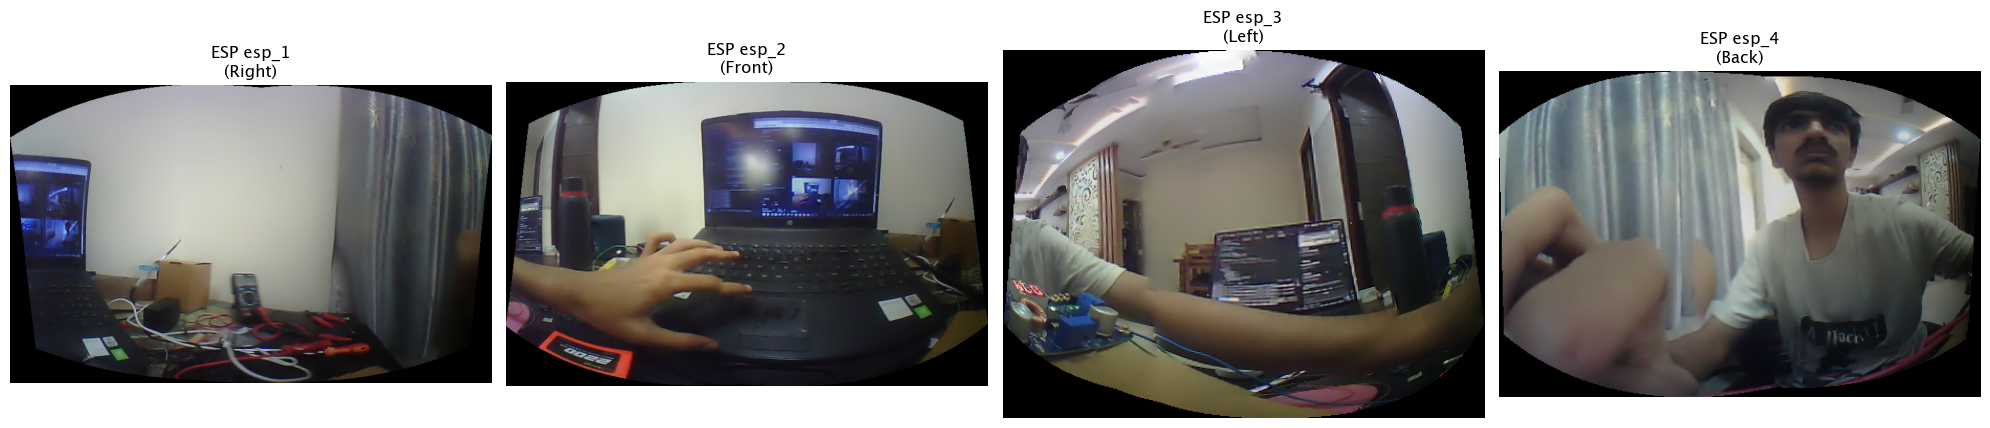

In [65]:
# Display the 4 ESP panoramas side by side
esp_images = []
esp_titles = []
for esp_id in sorted(esp_panoramas.keys()):
    position = ESP_POSITIONS.get(esp_id, "unknown")
    direction = {0: "Front", 90: "Left", 180: "Back", 270: "Right"}.get(position, f"{position}°")
    esp_images.append(esp_panoramas[esp_id])
    esp_titles.append(f"ESP {esp_id}\n({direction})")

plot_images(esp_images, titles=esp_titles, figsize=(20, 8))

## Cell 2: ORB feature extraction and visualization

ESP esp_1 (Right): 492 SIFT features detected
ESP esp_2 (Front): 661 SIFT features detected
ESP esp_3 (Left): 446 SIFT features detected
ESP esp_4 (Back): 284 SIFT features detected


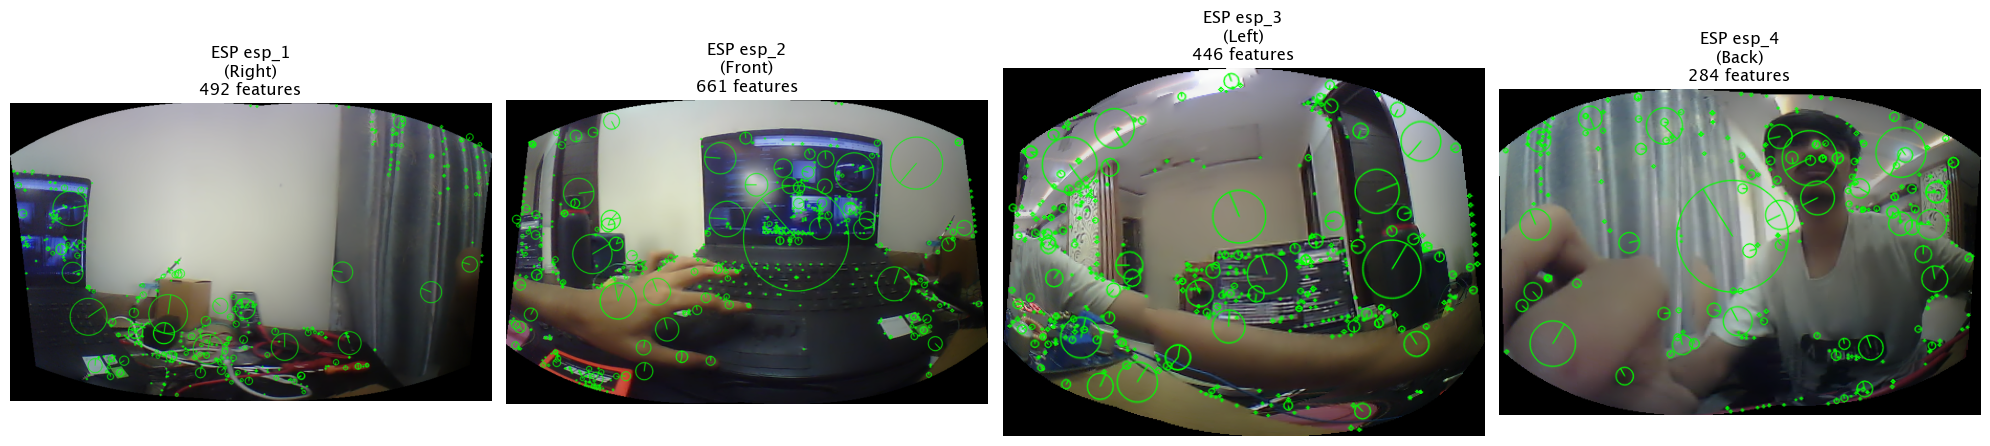

In [82]:
def detect_and_visualize_features(img, title="", n_features=5000):
    """Detect ORB features and return image with features drawn"""
    # Create ORB detector
    orb = cv.SIFT_create(nfeatures=n_features)

    # Detect keypoints
    keypoints, descriptors = orb.detectAndCompute(img, None)

    # Draw keypoints on image
    img_with_keypoints = cv.drawKeypoints(img, keypoints, None,
                                        color=(0, 255, 0),  # Green color
                                        flags=cv.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

    print(f"{title}: {len(keypoints)} SIFT features detected")
    return img_with_keypoints, keypoints, descriptors

# Detect features in all 4 ESP panoramas
feature_images = []
feature_titles = []

for esp_id in sorted(esp_panoramas.keys()):
    position = ESP_POSITIONS.get(esp_id, "unknown")
    direction = {0: "Front", 90: "Left", 180: "Back", 270: "Right"}.get(position, f"{position}°")

    img_with_features, keypoints, descriptors = detect_and_visualize_features(
        esp_panoramas[esp_id],
        f"ESP {esp_id} ({direction})",
        n_features=N_FEATURES_INTER
    )

    feature_images.append(img_with_features)
    feature_titles.append(f"ESP {esp_id}\n({direction})\n{len(keypoints)} features")

# Display feature visualizations side by side
plot_images(feature_images, titles=feature_titles, figsize=(20, 8))

## Cell 3: Identify and visualize good feature matches between ESP pairs

Matching adjacent ESP pairs: [('esp_2', 'esp_3'), ('esp_3', 'esp_4'), ('esp_4', 'esp_1'), ('esp_1', 'esp_2')]
ESP esp_2 ↔ ESP esp_3: 23 good matches
ESP esp_3 ↔ ESP esp_4: 45 good matches
ESP esp_4 ↔ ESP esp_1: 11 good matches
ESP esp_1 ↔ ESP esp_2: 41 good matches


/Users/diginova/learning/docucap/docucap/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8596 (\N{LEFT RIGHT ARROW}) missing from font(s) Lucida Grande.
  fig.canvas.print_figure(bytes_io, **kw)


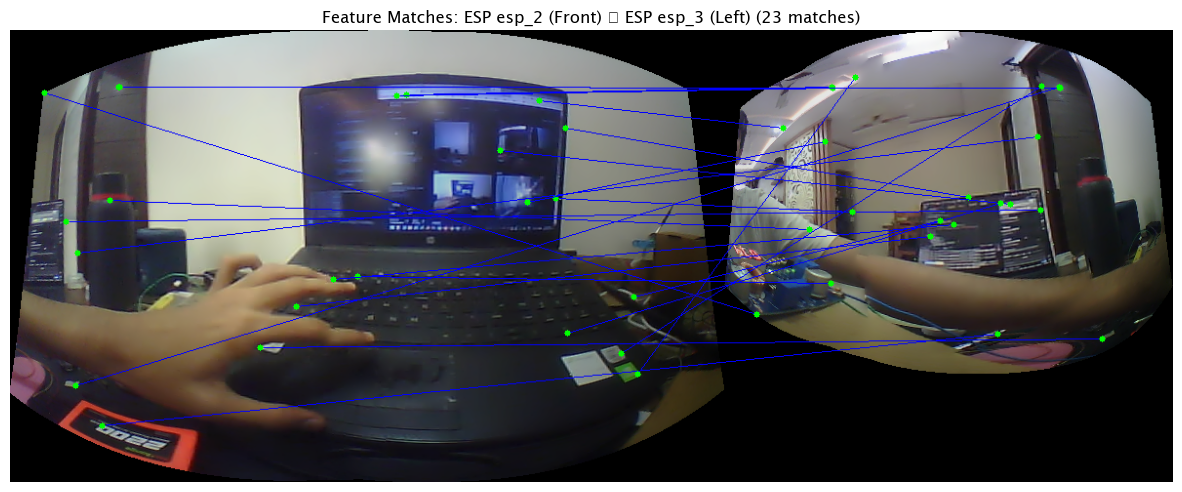

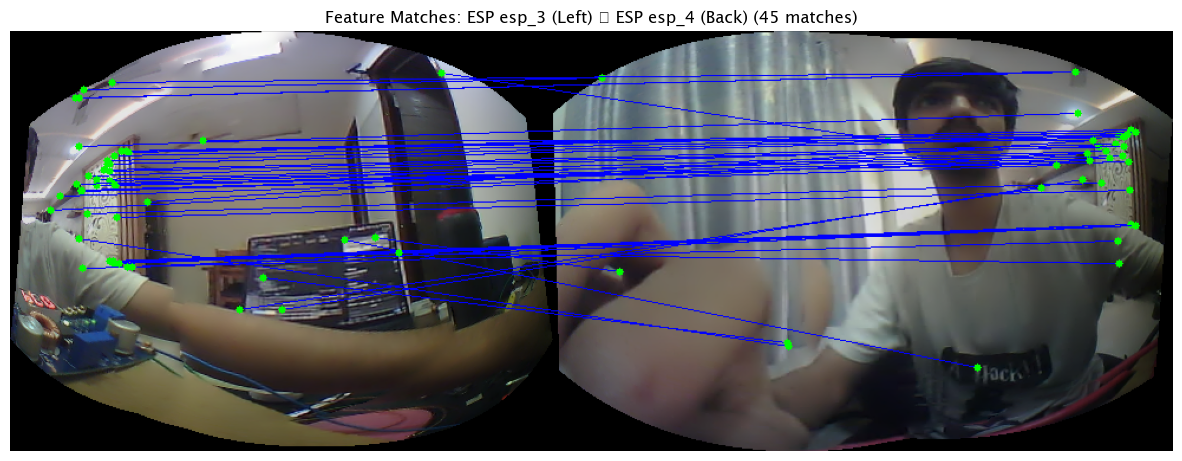

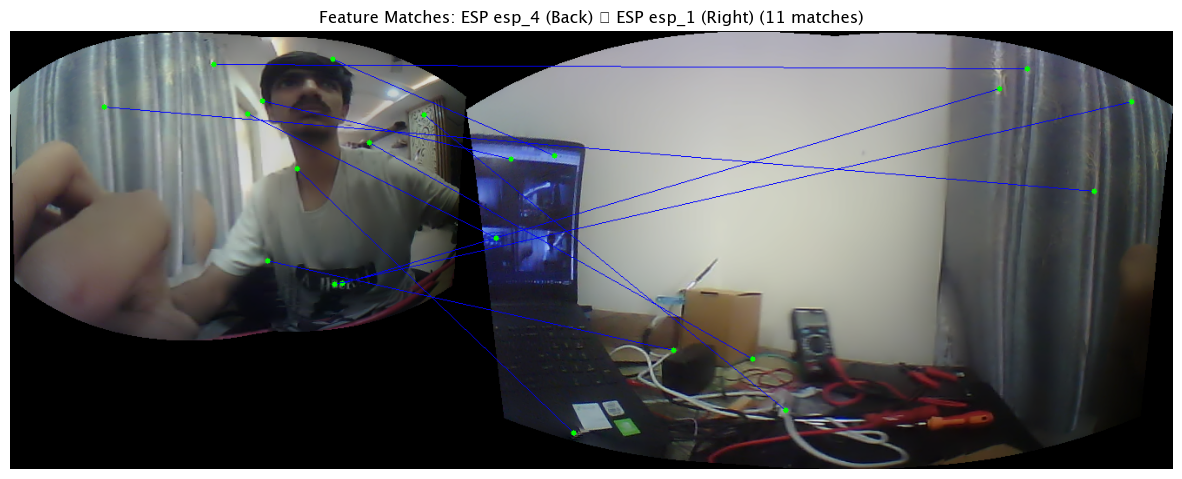

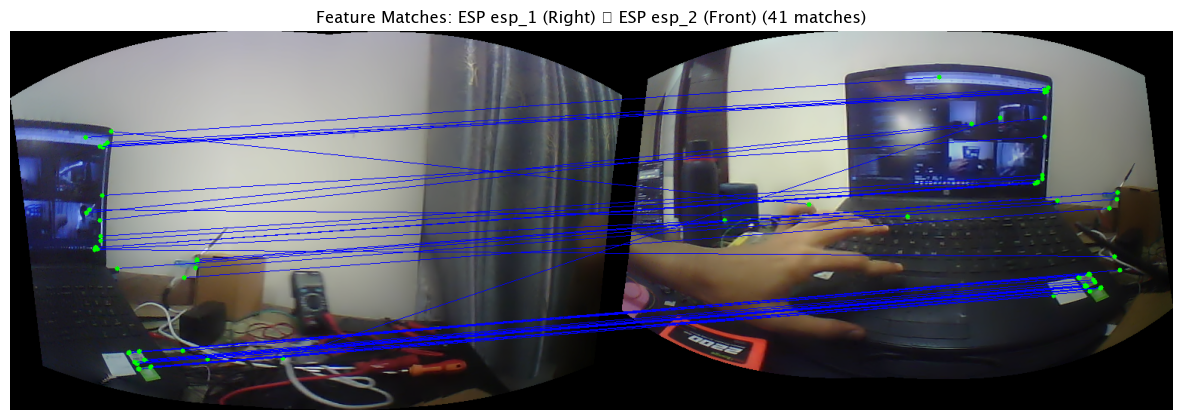

In [83]:
def find_good_matches_between_pairs(images, esp_ids, detector_type="orb", n_features=5000, positions=None):
    """Find good feature matches between adjacent pairs of ESP images"""
    # Detect features for all images
    all_keypoints = []
    all_descriptors = []

    for img in images:
        orb = cv.ORB_create(nfeatures=n_features)
        kp, desc = orb.detectAndCompute(img, None)
        all_keypoints.append(kp)
        all_descriptors.append(desc)

    # Define adjacent pairs based on angular positions
    adjacent_pairs = []
    if positions:
        # Sort ESPs by their angular position
        sorted_esps = sorted([(esp_id, pos) for esp_id, pos in positions.items()], key=lambda x: x[1])
        n = len(sorted_esps)

        # Create adjacent pairs (including wrap-around from last to first)
        for i in range(n):
            esp_i = sorted_esps[i][0]
            esp_j = sorted_esps[(i + 1) % n][0]  # Next ESP, wrapping around
            adjacent_pairs.append((esp_i, esp_j))
    else:
        # Fallback: assume esp_ids are in order and create sequential pairs
        n = len(esp_ids)
        for i in range(n):
            esp_i = esp_ids[i]
            esp_j = esp_ids[(i + 1) % n]  # Next ESP, wrapping around
            adjacent_pairs.append((esp_i, esp_j))

    print(f"Matching adjacent ESP pairs: {adjacent_pairs}")

    # Find matches only between adjacent pairs
    matches_info = {}

    for esp_i, esp_j in adjacent_pairs:
        # Find indices in our arrays
        try:
            idx_i = esp_ids.index(esp_i)
            idx_j = esp_ids.index(esp_j)
        except ValueError:
            continue

        # Match descriptors
        bf = cv.BFMatcher(cv.NORM_HAMMING, crossCheck=False)
        matches = bf.knnMatch(all_descriptors[idx_i], all_descriptors[idx_j], k=2)

        # Apply ratio test
        good_matches = []
        for m, n in matches:
            if m.distance < 0.75 * n.distance:
                good_matches.append(m)

        matches_info[(esp_i, esp_j)] = {
            'matches': good_matches,
            'keypoints1': all_keypoints[idx_i],
            'keypoints2': all_keypoints[idx_j]
        }

        print(f"ESP {esp_i} ↔ ESP {esp_j}: {len(good_matches)} good matches")

    return matches_info

def draw_matches_between_images(img1, img2, kp1, kp2, matches, title=""):
    """Draw feature matches between two images side by side"""
    # Create a combined image
    h1, w1 = img1.shape[:2]
    h2, w2 = img2.shape[:2]

    # Create canvas for side-by-side display
    canvas = np.zeros((max(h1, h2), w1 + w2, 3), dtype=np.uint8)

    # Place images side by side
    canvas[:h1, :w1] = img1
    canvas[:h2, w1:w1+w2] = img2

    # Draw lines connecting matched features
    for match in matches[:50]:  # Limit to first 50 matches for clarity
        # Get keypoint coordinates
        pt1 = (int(kp1[match.queryIdx].pt[0]), int(kp1[match.queryIdx].pt[1]))
        pt2 = (int(kp2[match.trainIdx].pt[0] + w1), int(kp2[match.trainIdx].pt[1]))

        # Draw line connecting the points
        cv.line(canvas, pt1, pt2, (255, 0, 0), 1)  # Blue line

        # Draw circles at feature points
        cv.circle(canvas, pt1, 3, (0, 255, 0), -1)  # Green circle
        cv.circle(canvas, pt2, 3, (0, 255, 0), -1)  # Green circle

    plt.figure(figsize=(15, 8))
    plt.imshow(cv.cvtColor(canvas, cv.COLOR_BGR2RGB))
    plt.title(f"{title} ({len(matches)} matches)")
    plt.axis('off')
    plt.show()

# Prepare images and ESP IDs in sorted order
esp_sorted = sorted(esp_panoramas.keys())
images_sorted = [esp_panoramas[esp_id] for esp_id in esp_sorted]

# Find matches between adjacent pairs only
matches_info = find_good_matches_between_pairs(images_sorted, esp_sorted, "orb", N_FEATURES_INTER, ESP_POSITIONS)

# Visualize matches for each pair
for (esp_i, esp_j), match_data in matches_info.items():
    pos_i = ESP_POSITIONS.get(esp_i, "unknown")
    pos_j = ESP_POSITIONS.get(esp_j, "unknown")
    dir_i = {0: "Front", 90: "Left", 180: "Back", 270: "Right"}.get(pos_i, f"{pos_i}°")
    dir_j = {0: "Front", 90: "Left", 180: "Back", 270: "Right"}.get(pos_j, f"{pos_j}°")

    title = f"Feature Matches: ESP {esp_i} ({dir_i}) ↔ ESP {esp_j} ({dir_j})"
    draw_matches_between_images(
        esp_panoramas[esp_i], esp_panoramas[esp_j],
        match_data['keypoints1'], match_data['keypoints2'],
        match_data['matches'], title
    )

## Cell 4: Optimize ESP angles for minimal feature match distances

In [84]:
def calculate_match_distances(matches_info, current_positions):
    """Calculate average feature match distances for current ESP positions"""
    total_distance = 0
    total_matches = 0

    for (esp_i, esp_j), match_data in matches_info.items():
        matches = match_data['matches']
        kp1 = match_data['keypoints1']
        kp2 = match_data['keypoints2']

        if len(matches) == 0:
            continue

        pair_distance = 0
        for match in matches:
            pt1 = kp1[match.queryIdx].pt
            pt2 = kp2[match.trainIdx].pt

            # Calculate Euclidean distance between matched points
            distance = np.sqrt((pt1[0] - pt2[0])**2 + (pt1[1] - pt2[1])**2)
            pair_distance += distance

        avg_pair_distance = pair_distance / len(matches)
        total_distance += avg_pair_distance * len(matches)
        total_matches += len(matches)

        print(f"ESP {esp_i} ↔ ESP {esp_j}: {len(matches)} matches, avg distance = {avg_pair_distance:.1f}")

    if total_matches == 0:
        return float('inf')

    overall_avg_distance = total_distance / total_matches
    return overall_avg_distance

def optimize_esp_angles(matches_info, initial_positions, max_iterations=50, learning_rate=0.5):
    """Optimize ESP angles to minimize feature match distances"""
    positions = initial_positions.copy()
    best_positions = positions.copy()
    best_distance = calculate_match_distances(matches_info, positions)

    print(f"\nStarting optimization with initial average distance: {best_distance:.2f}")
    print("Initial positions:", {esp: f"{pos}°" for esp, pos in positions.items()})

    for iteration in range(max_iterations):
        improved = False

        for esp_id in positions.keys():
            # Try small adjustments to this ESP's angle
            for delta in [-learning_rate, learning_rate]:
                test_positions = positions.copy()
                test_positions[esp_id] = (positions[esp_id] + delta) % 360

                test_distance = calculate_match_distances(matches_info, test_positions)

                if test_distance < best_distance:
                    best_distance = test_distance
                    best_positions = test_positions.copy()
                    improved = True
                    print(f"  Iteration {iteration+1}: ESP {esp_id} {delta:+.1f}° → distance {test_distance:.2f}")
                    break

            if improved:
                positions = best_positions.copy()
                break

        if not improved:
            print(f"No improvement found at iteration {iteration+1}, stopping")
            break

    print(f"\nOptimization complete after {iteration+1} iterations")
    print(f"Final average distance: {best_distance:.2f}")
    print("Optimized positions:", {esp: f"{pos:.1f}°" for esp, pos in best_positions.items()})

    return best_positions

# Calculate current match distances
print("Current feature match distances:")
current_avg_distance = calculate_match_distances(matches_info, ESP_POSITIONS)

# Optimize ESP angles
print(f"\n{'='*60}")
print("OPTIMIZING ESP ANGLES FOR MINIMAL FEATURE MATCH DISTANCES")
print(f"{'='*60}")

optimized_positions = optimize_esp_angles(matches_info, ESP_POSITIONS, max_iterations=20, learning_rate=1.0)

# Compare before and after
print(f"\n{'='*60}")
print("COMPARISON")
print(f"{'='*60}")
print("Original ESP positions:")
for esp_id, angle in ESP_POSITIONS.items():
    direction = {0: "Front", 90: "Left", 180: "Back", 270: "Right"}.get(angle, f"{angle}°")
    print(f"  ESP {esp_id}: {angle}° ({direction})")

print("\nOptimized ESP positions:")
for esp_id, angle in optimized_positions.items():
    direction = {0: "Front", 90: "Left", 180: "Back", 270: "Right"}.get(angle, f"{angle}°")
    print(f"  ESP {esp_id}: {angle:.1f}° ({direction})")

Current feature match distances:
ESP esp_2 ↔ ESP esp_3: 23 matches, avg distance = 291.4
ESP esp_3 ↔ ESP esp_4: 45 matches, avg distance = 344.5
ESP esp_4 ↔ ESP esp_1: 11 matches, avg distance = 338.4
ESP esp_1 ↔ ESP esp_2: 41 matches, avg distance = 420.7

OPTIMIZING ESP ANGLES FOR MINIMAL FEATURE MATCH DISTANCES
ESP esp_2 ↔ ESP esp_3: 23 matches, avg distance = 291.4
ESP esp_3 ↔ ESP esp_4: 45 matches, avg distance = 344.5
ESP esp_4 ↔ ESP esp_1: 11 matches, avg distance = 338.4
ESP esp_1 ↔ ESP esp_2: 41 matches, avg distance = 420.7

Starting optimization with initial average distance: 359.78
Initial positions: {'esp_2': '0°', 'esp_3': '90°', 'esp_1': '270°', 'esp_4': '180°'}
ESP esp_2 ↔ ESP esp_3: 23 matches, avg distance = 291.4
ESP esp_3 ↔ ESP esp_4: 45 matches, avg distance = 344.5
ESP esp_4 ↔ ESP esp_1: 11 matches, avg distance = 338.4
ESP esp_1 ↔ ESP esp_2: 41 matches, avg distance = 420.7
ESP esp_2 ↔ ESP esp_3: 23 matches, avg distance = 291.4
ESP esp_3 ↔ ESP esp_4: 45 matches,